# Importing and opening the Hugging Face Dataset (Our main training dataset)


In [ ]:
from huggingface_hub import hf_hub_download
import json

file_path = hf_hub_download(
    repo_id="OSS-forge/HumanVsAICode",
    filename="python_dataset.jsonl",
    repo_type="dataset"
)

print("File downloaded to:", file_path)

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


python_dataset.jsonl:   0%|          | 0.00/652M [00:00<?, ?B/s]

File downloaded to: /root/.cache/huggingface/hub/datasets--OSS-forge--HumanVsAICode/snapshots/03cac5dd2096c8901cb7a74e2ecbd26624ada497/python_dataset.jsonl


# Preprocessing (Organizing the dataset's columns to make a df that is easy to use for training)


In [ ]:

import pandas as pd
from datasets import Dataset, DatasetDict

df = pd.DataFrame(data)

code_cols = ['human_code', 'chatgpt_code', 'dsc_code', 'qwen_code']
df_long = df.melt(id_vars=['docstring'], value_vars=code_cols,
                  var_name='writer_type', value_name='code')

df_long['writer'] = df_long['writer_type'].map({
    'human_code': 'human',
    'chatgpt_code': 'gpt',
    'dsc_code': 'dsc',
    'qwen_code': 'qwen'
})
df_long['is_ai'] = (df_long['writer'] != 'human').astype(int)

data_df = df_long[['docstring', 'code', 'writer', 'is_ai']]

dataset = Dataset.from_pandas(data_df)

# Since the dataset is so large, I am taking 1/3 of the samples of each writer (gpt, qwen, dsc, human)


In [ ]:

SAMPLE_FRAC = 1 / 3
RANDOM_SEED = 42

sampled_df = (
    data_df
    .groupby('writer', group_keys=False)
    .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

small_dataset = Dataset.from_pandas(sampled_df)

dataset_dict = small_dataset.train_test_split(
    test_size=0.2,
    seed=42,
)


writer
human    285249
gpt      285249
dsc      285249
qwen     285249
Name: count, dtype: int64


/tmp/ipython-input-201977150.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED))


# Loading the CodeBERT model and saving embeddings to Drive

In [ ]:
from google.colab import drive
import os
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

drive.mount("/content/drive", force_remount=True)

BASE_DIR = "/content/drive/MyDrive/codebert_embeddings"
os.makedirs(BASE_DIR, exist_ok=True)
print("Saving embeddings to:", BASE_DIR)


MODEL_NAME = "microsoft/codebert-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()


def codebert_embeddings_batch(texts, batch_size=16, max_length=256):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="CodeBERT embedding"):
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_length
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)


def embed_and_save(dataset, name="all_llms", batch_size=16, max_length=256):

    texts = [
        (item["docstring"] or "") + "\n\n" + item["code"]
        for item in dataset
    ]

    y = np.array([item["is_ai"] for item in dataset])

    X = codebert_embeddings_batch(
        texts,
        batch_size=batch_size,
        max_length=max_length
    )

    save_path = f"{BASE_DIR}/codebert_{name}.pt"

    torch.save(
        {
            "X": X,
            "y": y,
            "model": MODEL_NAME,
            "max_length": max_length,
            "batch_size": batch_size,
            "n_samples": len(y),
        },
        save_path
    )

    print(f"Embeddings saved to → {save_path}")
    print(f"Shapes: X={X.shape}, y={y.shape}")
    print(f"AI ratio: {y.mean():.3f}")

    del X, y, texts
    torch.cuda.empty_cache()

embed_and_save(small_dataset, name="human_gpt_qwen_dsc")


Mounted at /content/drive
Saving embeddings to: /content/drive/MyDrive/codebert_embeddings
Using device: cuda


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


🚀 Processing unified dataset: human_gpt_qwen_dsc


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

CodeBERT embedding: 100%|██████████| 23771/23771 [1:33:52<00:00,  4.22it/s]


✅ Saved unified embeddings → /content/drive/MyDrive/codebert_embeddings/codebert_human_gpt_qwen_dsc.pt
   Shapes: X=(380332, 768), y=(380332,)
   AI ratio: 0.750


# Loading the saved embeddings

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

base = "/content/drive/MyDrive/codebert_embeddings"

data = torch.load(
    f"{base}/codebert_human_gpt_qwen_dsc.pt",
    map_location="cpu",
    weights_only=False
)

X = data["X"]
y = data["y"]

print("Loaded embeddings:", X.shape, y.shape)
print("AI ratio:", y.mean())


Loaded embeddings: (380332, 768) (380332,)
AI ratio: 0.75


# Splitting the data and training the LR

In [ ]:
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = LogisticRegression(
    max_iter=500,
    solver="lbfgs",
    C=0.1,
    n_jobs=-1
)

clf.fit(X_tr, y_tr)


LogisticRegression(C=0.1, max_iter=500, n_jobs=-1)

# Displaying the results

Validation Accuracy: 0.899
Validation AUROC:   0.950


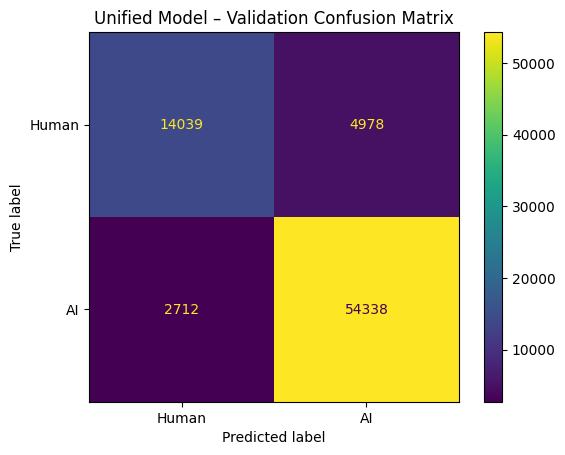

In [ ]:
probs = clf.predict_proba(X_va)[:, 1]
preds = (probs >= 0.5).astype(int)

acc = accuracy_score(y_va, preds)
auc = roc_auc_score(y_va, probs)

print(f"Validation Accuracy: {acc:.3f}")
print(f"Validation AUROC:   {auc:.3f}")

cm = confusion_matrix(y_va, preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)
disp.plot()
plt.title("Unified Model – Validation Confusion Matrix")
plt.show()


# Loading the new dataset from GitHub for testing

In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ----------------------------------
# 1) Load the external dataset CSV
# ----------------------------------
csv_path = "/content/drive/MyDrive/AI-Human-Generated-Program-Code-Dataset(1).csv"
df = pd.read_csv(csv_path)

# ----------------------------------
# 2) Keep ONLY Python rows
# ----------------------------------
df = df[df["language"].str.lower() == "python"]

print("Python-only rows:", len(df))

# ----------------------------------
# 3) Create AI + Human datasets
# ----------------------------------
ai_df = df[['id', 'problem_number', 'language', 'difficulty',
            'generator_name', 'generator_type',
            'description', 'prompt', 'ai_generated_code']].copy()
ai_df = ai_df.rename(columns={'ai_generated_code': 'code'})
ai_df['is_ai'] = 1

human_df = df[['id', 'problem_number', 'language', 'difficulty',
               'generator_name', 'generator_type',
               'description', 'prompt', 'human_generated_code']].copy()
human_df = human_df.rename(columns={'human_generated_code': 'code'})
human_df['is_ai'] = 0

# ----------------------------------
# 4) Combine + clean
# ----------------------------------
combined_df = pd.concat([ai_df, human_df], ignore_index=True)

combined_df = combined_df[
    combined_df['code'].notna() &
    (combined_df['code'].str.strip() != "")
]

print("Final Python samples:", len(combined_df))
print("AI ratio:", combined_df['is_ai'].mean())

# ----------------------------------
# 5) Prepare for embedding
# ----------------------------------
texts = combined_df['code'].tolist()
y_new = combined_df['is_ai'].values

X_new = codebert_embeddings_batch(
    texts,
    batch_size=16,
    max_length=256
)


Python-only rows: 30
Final Python samples: 60
AI ratio: 0.5


CodeBERT embedding: 100%|██████████| 4/4 [00:00<00:00,  4.24it/s]


# Displaying results

NEW DATA | Acc: 0.633 | AUROC: 0.539


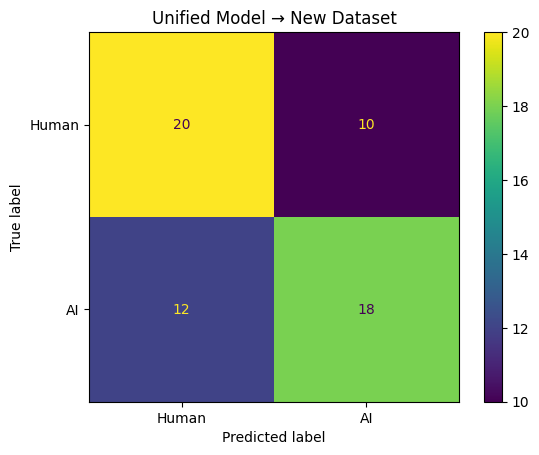

In [ ]:
probs_new = clf.predict_proba(X_new)[:, 1]
preds_new = (probs_new >= 0.5).astype(int)

acc_new = accuracy_score(y_new, preds_new)
auc_new = roc_auc_score(y_new, probs_new)

print(f"NEW DATA | Acc: {acc_new:.3f} | AUROC: {auc_new:.3f}")

cm_new = confusion_matrix(y_new, preds_new)
ConfusionMatrixDisplay(
    cm_new,
    display_labels=["Human", "AI"]
).plot()
plt.title("Unified Model → New Dataset")
plt.show()


# From here on I am expermenting ways to improve the accuracy. This is where I make my pairwise datasets and trained 3 different models with the three difference LLM generated code.

In [ ]:
def make_pairwise_dataset(dataset, ai_writer, seed=42):
    """
    Create a dataset with:
    - human
    - one specific AI writer (gpt / qwen / dsc)
    """
    return dataset.filter(
        lambda x: x["writer"] in ["human", ai_writer]
    )

human_gpt = make_pairwise_dataset(dataset, "gpt")
human_qwen = make_pairwise_dataset(dataset, "qwen")
human_dsc = make_pairwise_dataset(dataset, "dsc")

Filter:   0%|          | 0/1140996 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1140996 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1140996 [00:00<?, ? examples/s]

In [ ]:
split1 = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split1['train']
temp_dataset = split1['test']

split2 = temp_dataset.train_test_split(test_size=0.5, seed=42)
val_dataset = split2['train']
test_dataset = split2['test']

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 912796
Validation size: 114100
Test size: 114100


In [ ]:
!pip install -U --no-cache-dir scikit-learn==1.4.2 transformers==4.38.2 torch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 296.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 256.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 296.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 251.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 322.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 159.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 449.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 345.1 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.5.0
    Uninstalling triton-3.5.0:
      Successfully uninstalled triton-3.5.0
  Attempting uninstall: nvidia-nvshmem-cu12
    Found existing installation: nvidia-nvshmem-cu12 3.3.20
    Uninstalling nvidia

# Here I am embedding and saving all three datasets

In [ ]:

from google.colab import drive
import os
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

drive.mount("/content/drive", force_remount=True)

BASE_DIR = "/content/drive/MyDrive/codebert_embeddings"
os.makedirs(BASE_DIR, exist_ok=True)
print("Saving embeddings to:", BASE_DIR)


MODEL_NAME = "microsoft/codebert-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()


def codebert_embeddings_batch(texts, batch_size=16, max_length=256):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="CodeBERT embedding"):
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_length
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)


def embed_and_save(dataset, name, batch_size=16, max_length=256):
    print(f"\n🚀 Processing {name}")

    texts = [
        item["docstring"] + "\n\n" + item["code"]
        for item in dataset
    ]

    y = np.array([item["is_ai"] for item in dataset])

    X = codebert_embeddings_batch(
        texts,
        batch_size=batch_size,
        max_length=max_length
    )

    save_path = f"{BASE_DIR}/codebert_{name}.pt"

    torch.save(
        {
            "X": X,
            "y": y,
            "model": MODEL_NAME,
            "max_length": max_length,
            "batch_size": batch_size,
        },
        save_path
    )

    print(f"Saved {name} → {save_path}")
    print(f"Shapes: X={X.shape}, y={y.shape}")

    # Free memory
    del X, y, texts
    torch.cuda.empty_cache()


embed_and_save(human_gpt,  "human_gpt")
embed_and_save(human_qwen, "human_qwen")
embed_and_save(human_dsc,  "human_dsc")

print("\n All available embeddings processed and saved!")


Mounted at /content/drive
Saving embeddings to: /content/drive/MyDrive/codebert_embeddings
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



🚀 Processing human_gpt


CodeBERT embedding: 100%|██████████| 35657/35657 [2:21:41<00:00,  4.19it/s]


✅ Saved human_gpt → /content/drive/MyDrive/codebert_embeddings/codebert_human_gpt.pt
   Shapes: X=(570498, 768), y=(570498,)

🚀 Processing human_qwen


CodeBERT embedding: 100%|██████████| 35657/35657 [2:22:41<00:00,  4.16it/s]


✅ Saved human_qwen → /content/drive/MyDrive/codebert_embeddings/codebert_human_qwen.pt
   Shapes: X=(570498, 768), y=(570498,)

🚀 Processing human_dsc


CodeBERT embedding: 100%|██████████| 35657/35657 [2:22:27<00:00,  4.17it/s]


✅ Saved human_dsc → /content/drive/MyDrive/codebert_embeddings/codebert_human_dsc.pt
   Shapes: X=(570498, 768), y=(570498,)

🎉 All available embeddings processed and saved!


# Trained and tested 1/3 of the datasets (human vs gpt) and displayed results through various graphs

In [ ]:
import torch

from google.colab import drive
drive.mount("/content/drive")

data = torch.load(
    "/content/drive/MyDrive/codebert_embeddings/codebert_human_gpt.pt",
    map_location="cpu",
    weights_only=False
)

X = data["X"]
y = data["y"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)


X_train: (456398, 768)
X_val: (114100, 768)


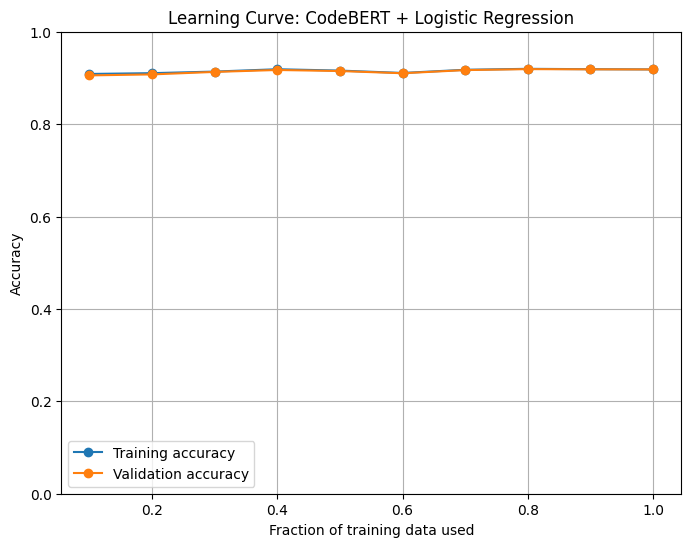

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

fractions = np.linspace(0.1, 1.0, 10)

train_acc = []
val_acc = []
used_fractions = []

# shuffle once
perm = np.random.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]

for frac in fractions:
    n_samples = max(2, int(len(X_train) * frac))

    X_subset = X_train[:n_samples]
    y_subset = y_train[:n_samples]

    # skip if only one class
    if len(np.unique(y_subset)) < 2:
        continue

    clf = LogisticRegression(
        max_iter=300,
        solver="lbfgs",
        tol=1e-3,
        C=0.1
    )

    clf.fit(X_subset, y_subset)

    used_fractions.append(frac)
    train_acc.append(accuracy_score(y_subset, clf.predict(X_subset)))
    val_acc.append(accuracy_score(y_val, clf.predict(X_val)))

plt.figure(figsize=(8, 6))
plt.plot(used_fractions, train_acc, "o-", label="Training accuracy")
plt.plot(used_fractions, val_acc, "o-", label="Validation accuracy")

plt.xlabel("Fraction of training data used")
plt.ylabel("Accuracy")
plt.title("Learning Curve: CodeBERT + Logistic Regression")
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.show()


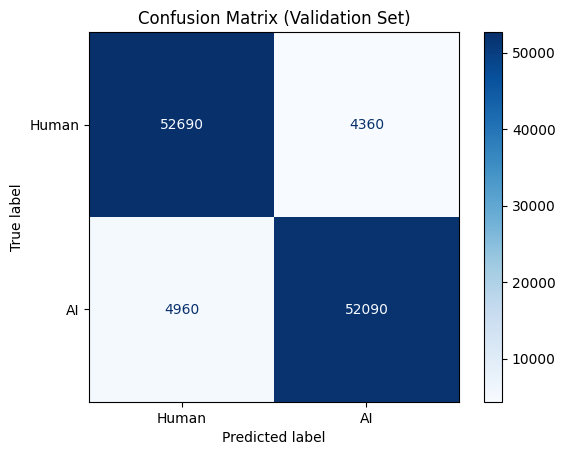

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on validation set
y_val_pred = clf.predict(X_val)

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Validation Set)")
plt.show()


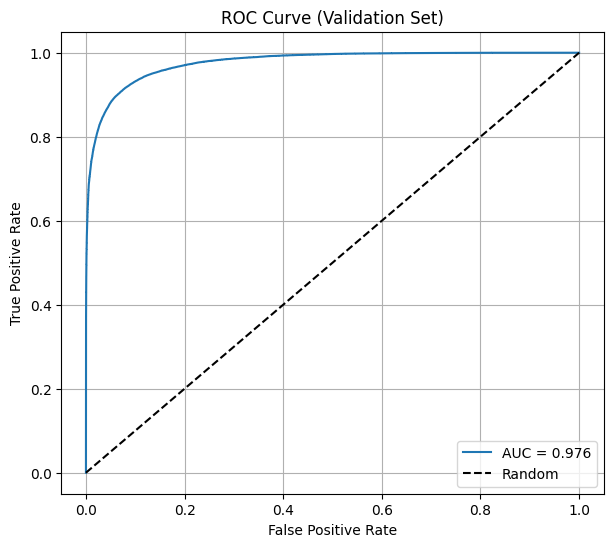

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probability for positive class (AI = 1)
y_val_probs = clf.predict_proba(X_val)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation Set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


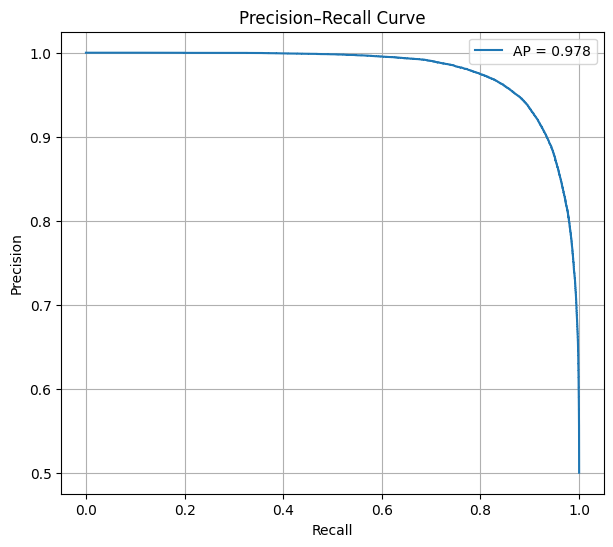

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, y_val_probs)
ap = average_precision_score(y_val, y_val_probs)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


# Training and testing all three datasets, also testing each model every other dataset


=== Train on HUMAN vs GPT ===
Test on HUMAN vs GPT   | Acc: 0.927 | AUROC: 0.981
Test on HUMAN vs QWEN  | Acc: 0.619 | AUROC: 0.757
Test on HUMAN vs DSC   | Acc: 0.863 | AUROC: 0.942


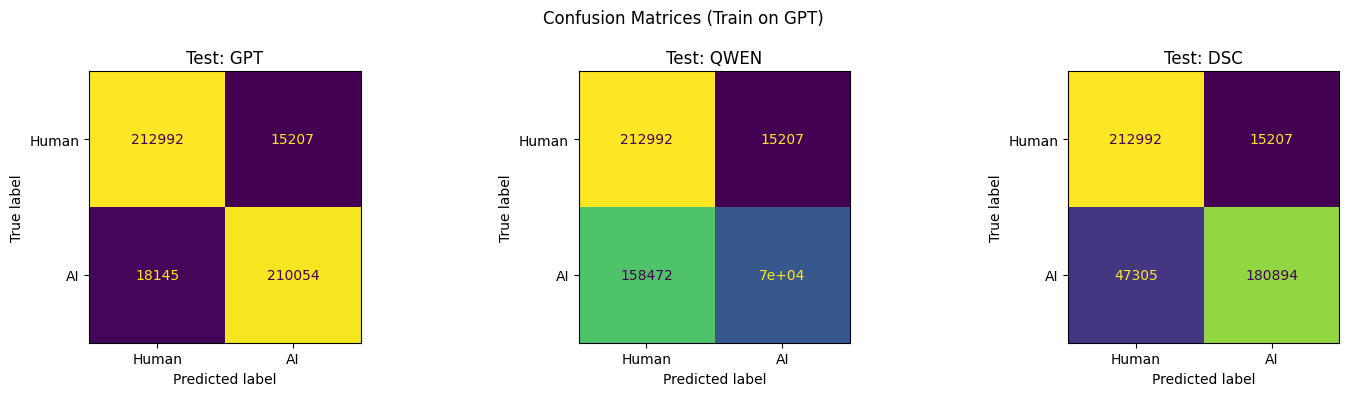

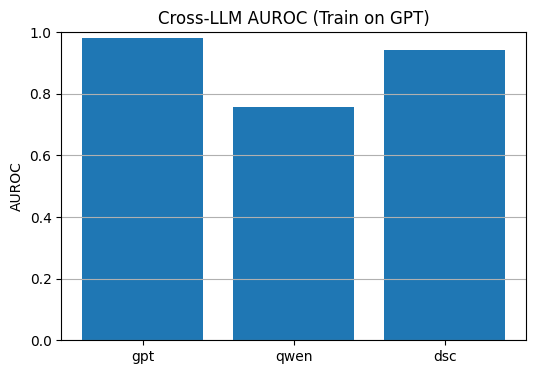


=== Train on HUMAN vs QWEN ===
Test on HUMAN vs GPT   | Acc: 0.813 | AUROC: 0.900
Test on HUMAN vs QWEN  | Acc: 0.863 | AUROC: 0.940
Test on HUMAN vs DSC   | Acc: 0.843 | AUROC: 0.923


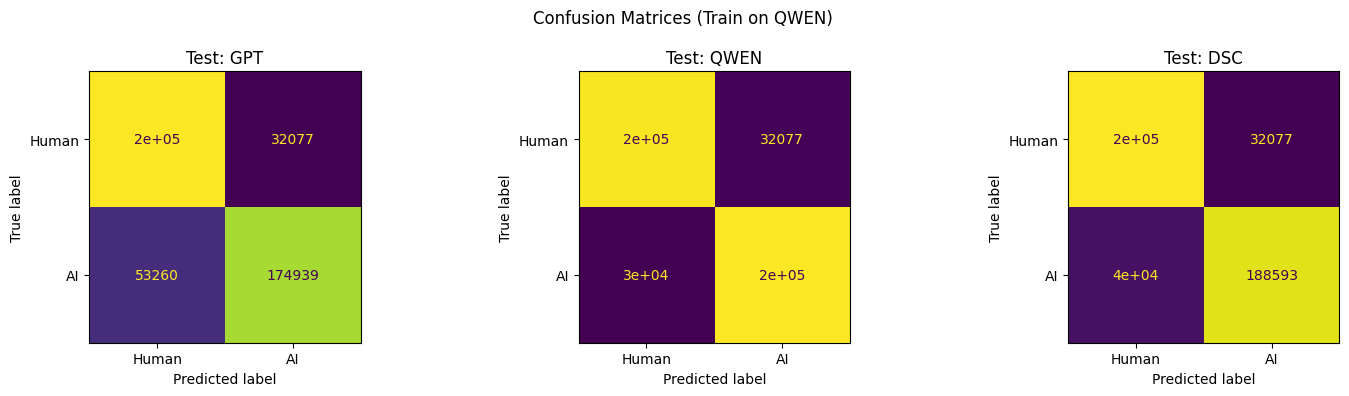

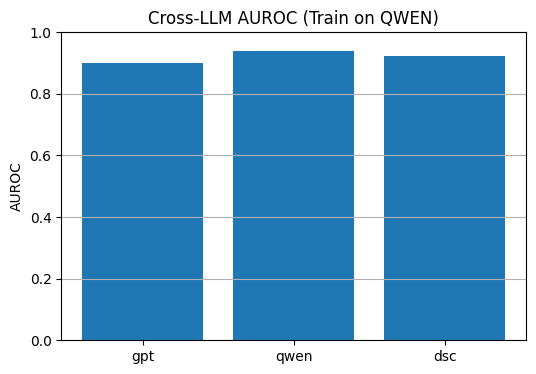


=== Train on HUMAN vs DSC ===
Test on HUMAN vs GPT   | Acc: 0.857 | AUROC: 0.949
Test on HUMAN vs QWEN  | Acc: 0.669 | AUROC: 0.829
Test on HUMAN vs DSC   | Acc: 0.939 | AUROC: 0.985


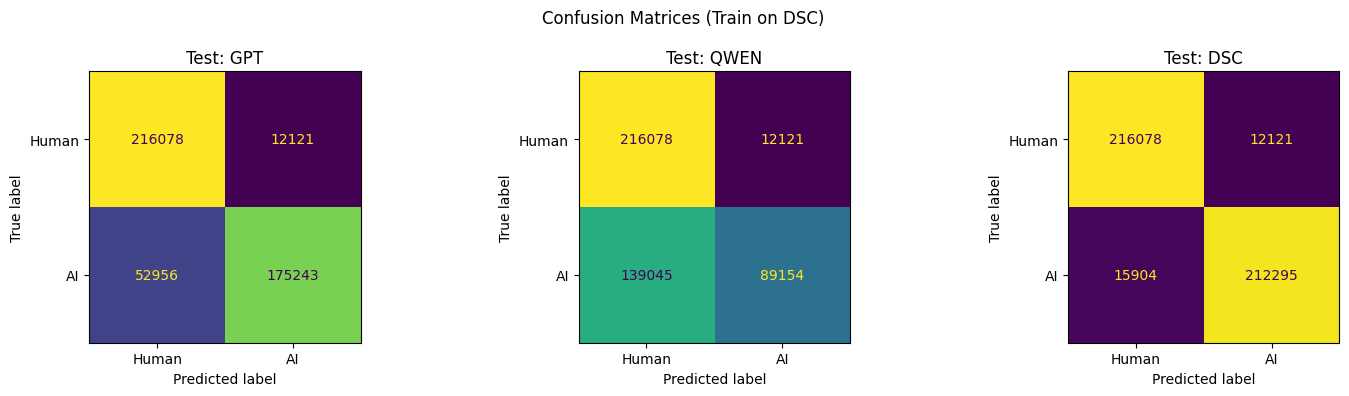

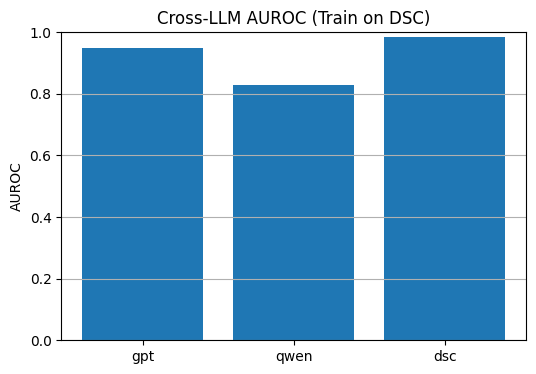

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split


base = "/content/drive/MyDrive/codebert_embeddings"

def load_embeddings(name):
    data = torch.load(
        f"{base}/codebert_human_{name}.pt",
        map_location="cpu",
        weights_only=False
    )
    return data["X"], data["y"]

X_gpt,  y_gpt  = load_embeddings("gpt")
X_qwen, y_qwen = load_embeddings("qwen")
X_dsc,  y_dsc  = load_embeddings("dsc")


def split(X, y):
    return train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

splits = {
    "gpt":  split(X_gpt, y_gpt),
    "qwen": split(X_qwen, y_qwen),
    "dsc":  split(X_dsc, y_dsc)
}


def train_eval_plot(train_name):
    X_tr, X_va, y_tr, y_va = splits[train_name]

    clf = LogisticRegression(
        max_iter=500,
        solver="lbfgs",
        C=0.1,
        n_jobs=-1
    )
    clf.fit(X_tr, y_tr)

    aucs = {}
    fig_cm, axes_cm = plt.subplots(1, 3, figsize=(15, 4))

    print(f"\n=== Train on HUMAN vs {train_name.upper()} ===")

    for ax, (test_name, (Xt, _, yt, yv)) in zip(
        axes_cm,
        splits.items()
    ):
        probs = clf.predict_proba(Xt)[:, 1]
        preds = (probs >= 0.5).astype(int)

        acc = accuracy_score(yt, preds)
        auc = roc_auc_score(yt, probs)
        aucs[test_name] = auc

        print(f"Test on HUMAN vs {test_name.upper():<5} | "
              f"Acc: {acc:.3f} | AUROC: {auc:.3f}")

        cm = confusion_matrix(yt, preds)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Human", "AI"]
        )
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(f"Test: {test_name.upper()}")

    plt.suptitle(f"Confusion Matrices (Train on {train_name.upper()})")
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.bar(aucs.keys(), aucs.values())
    plt.ylim(0.0, 1.0)
    plt.ylabel("AUROC")
    plt.title(f"Cross-LLM AUROC (Train on {train_name.upper()})")
    plt.grid(axis="y")
    plt.show()



for name in ["gpt", "qwen", "dsc"]:
    train_eval_plot(name)


# Testing all three new models with the new GitHub dataset again to see if accuracy increased at all

In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)


csv_path = "/content/drive/MyDrive/AI-Human-Generated-Program-Code-Dataset(1).csv"
df = pd.read_csv(csv_path)


ai_df = df[['id', 'problem_number', 'language', 'difficulty', 'generator_name',
            'generator_type', 'description', 'prompt', 'ai_generated_code']].copy()
ai_df = ai_df.rename(columns={'ai_generated_code': 'code'})  # unify column
ai_df['is_ai'] = 1


human_df = df[['id', 'problem_number', 'language', 'difficulty', 'generator_name',
               'generator_type', 'description', 'prompt', 'human_generated_code']].copy()
human_df = human_df.rename(columns={'human_generated_code': 'code'})  # unify column
human_df['is_ai'] = 0


combined_df = pd.concat([ai_df, human_df], ignore_index=True)


combined_df = combined_df[combined_df['code'].notna()]


texts = combined_df['code'].tolist()
y_new = combined_df['is_ai'].values


X_new = codebert_embeddings_batch(
    texts,
    batch_size=16,
    max_length=256
)



CodeBERT embedding: 100%|██████████| 12/12 [00:02<00:00,  5.40it/s]

(180, 768)



=== Train on HUMAN vs GPT ===
Test on NEW DATA | Acc: 0.589 | AUROC: 0.674


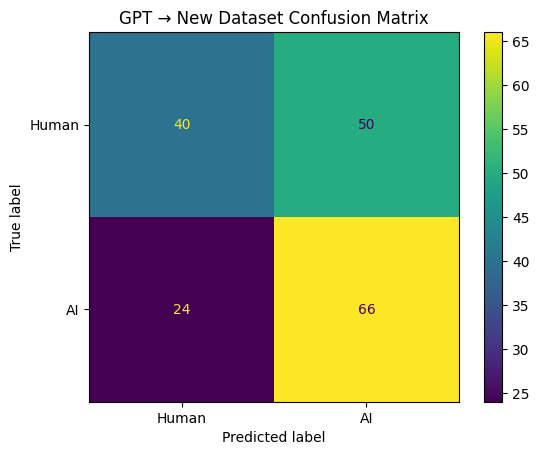


=== Train on HUMAN vs QWEN ===
Test on NEW DATA | Acc: 0.550 | AUROC: 0.540


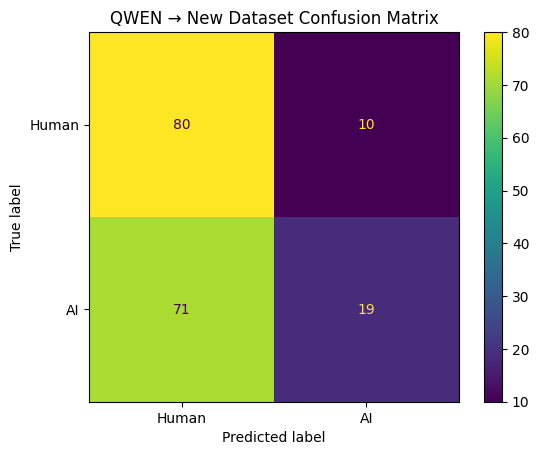


=== Train on HUMAN vs DSC ===
Test on NEW DATA | Acc: 0.500 | AUROC: 0.527


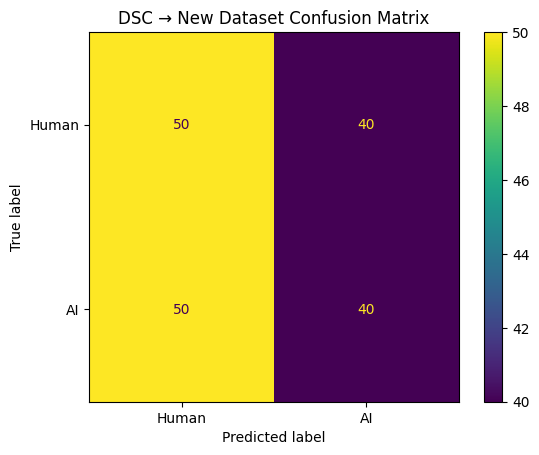

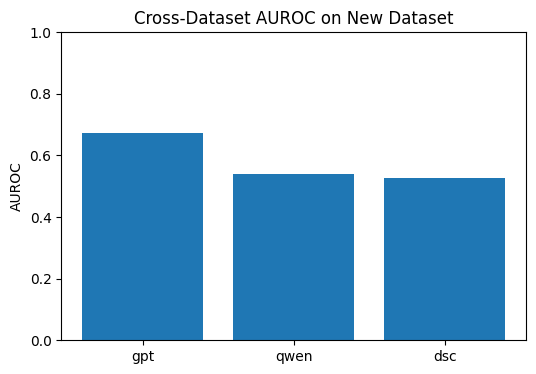

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split


base = "/content/drive/MyDrive/codebert_embeddings"

def load_embeddings(name):
    data = torch.load(
        f"{base}/codebert_human_{name}.pt",
        map_location="cpu",
        weights_only=False
    )
    return data["X"], data["y"]

X_gpt,  y_gpt  = load_embeddings("gpt")
X_qwen, y_qwen = load_embeddings("qwen")
X_dsc,  y_dsc  = load_embeddings("dsc")


def split(X, y):
    return train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

splits = {
    "gpt":  split(X_gpt, y_gpt),
    "qwen": split(X_qwen, y_qwen),
    "dsc":  split(X_dsc, y_dsc)
}


def train_eval_on_new(train_name, X_test, y_test):
    X_tr, X_va, y_tr, y_va = splits[train_name]

    clf = LogisticRegression(
        max_iter=500,
        solver="lbfgs",
        C=0.1,
        n_jobs=-1
    )
    clf.fit(X_tr, y_tr)


    probs = clf.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f"\n=== Train on HUMAN vs {train_name.upper()} ===")
    print(f"Test on NEW DATA | Acc: {acc:.3f} | AUROC: {auc:.3f}")


    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Human", "AI"]
    )
    disp.plot()
    plt.title(f"{train_name.upper()} → New Dataset Confusion Matrix")
    plt.show()

    return clf, acc, auc


results = {}
for name in ["gpt", "qwen", "dsc"]:
    clf, acc, auc = train_eval_on_new(name, X_new, y_new)
    results[name] = {"clf": clf, "accuracy": acc, "auc": auc}


plt.figure(figsize=(6,4))
plt.bar(results.keys(), [r["auc"] for r in results.values()])
plt.ylim(0,1)
plt.ylabel("AUROC")
plt.title("Cross-Dataset AUROC on New Dataset")
plt.show()


# From here on I am combining AST feature extractions with CodeBERT to see if this can improve accuracy

In [ ]:
from huggingface_hub import hf_hub_download
import json

import pandas as pd
from datasets import Dataset, DatasetDict

# Loading dataset
file_path = hf_hub_download(
    repo_id="OSS-forge/HumanVsAICode",
    filename="python_dataset.jsonl",
    repo_type="dataset"
)

print("File downloaded to:", file_path)

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

# Creating Dataframe and organizing data
df = pd.DataFrame(data)

code_cols = ['human_code', 'chatgpt_code', 'dsc_code', 'qwen_code']
df_long = df.melt(id_vars=['docstring'], value_vars=code_cols,
                  var_name='writer_type', value_name='code')

df_long['writer'] = df_long['writer_type'].map({
    'human_code': 'human',
    'chatgpt_code': 'gpt',
    'dsc_code': 'dsc',
    'qwen_code': 'qwen'
})
df_long['is_ai'] = (df_long['writer'] != 'human').astype(int)

data_df = df_long[['docstring', 'code', 'writer', 'is_ai']]

dataset = Dataset.from_pandas(data_df)

# Getting a smaller subsample
SAMPLE_FRAC = 1 / 3
RANDOM_SEED = 42

sampled_df = (
    data_df
    .groupby('writer', group_keys=False)
    .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

small_dataset = Dataset.from_pandas(sampled_df)

dataset_dict = small_dataset.train_test_split(
    test_size=0.2,
    seed=42,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


python_dataset.jsonl:   0%|          | 0.00/652M [00:00<?, ?B/s]

File downloaded to: /root/.cache/huggingface/hub/datasets--OSS-forge--HumanVsAICode/snapshots/03cac5dd2096c8901cb7a74e2ecbd26624ada497/python_dataset.jsonl


/tmp/ipykernel_13961/3532532924.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED))


In [ ]:
import ast
import tokenize
import io
import math
from collections import Counter
import numpy as np

class ASTFeatureExtractor(ast.NodeVisitor):

    CONTROL_NODES = (
        ast.If, ast.For, ast.While,
        ast.Try, ast.FunctionDef, ast.ClassDef
    )

    def __init__(self):

        self.FEATURE_NAMES = [
            # structural counts (normalized later)
            "if_count",
            "loop_count",
            "return_count",

            # structure
            "functions",
            "classes",
            "docstrings",

            # depth
            "max_control_depth",

            # function statistics
            "avg_function_length",
            "max_function_length",
            "functions_per_100_lines",

            # identifiers
            "unique_identifiers",
            "avg_identifier_length",
            "single_char_identifiers",
            "identifier_entropy",

            # error / defensive coding
            "error_handling_count",
            "error_handling_per_function",
            "empty_except_blocks",

            # comments
            "comment_count",
            "comment_density",
            "avg_comment_length",
            "todo_comments",

            # misc
            "pass_statements"
        ]

        self.reset()

    # ---------- state ----------

    def reset(self):
        self.features = Counter()
        self.identifiers = []

        self.function_lengths = []

        self.curr_depth = 0
        self.max_depth = 0

        self.comment_count = 0
        self.comment_lengths = []
        self.todo_comments = 0

        self.empty_except_blocks = 0
        self.pass_statements = 0

        self.total_lines = 0

    # ---------- depth handling ----------

    def generic_visit(self, node):
        is_control = isinstance(node, self.CONTROL_NODES)
        if is_control:
            self.curr_depth += 1
            self.max_depth = max(self.max_depth, self.curr_depth)

        super().generic_visit(node)

        if is_control:
            self.curr_depth -= 1

    # ---------- control flow ----------

    def visit_If(self, node):
        self.features["if_count"] += 1
        self.generic_visit(node)

    def visit_For(self, node):
        self.features["loop_count"] += 1
        self.generic_visit(node)

    def visit_While(self, node):
        self.features["loop_count"] += 1
        self.generic_visit(node)

    def visit_Return(self, node):
        self.features["return_count"] += 1
        self.generic_visit(node)

    # ---------- error handling ----------

    def visit_Try(self, node):
        self.features["error_handling_count"] += 1

        if not node.handlers or all(len(h.body) == 0 for h in node.handlers):
            self.empty_except_blocks += 1

        self.generic_visit(node)

    def visit_Assert(self, node):
        self.features["error_handling_count"] += 1
        self.generic_visit(node)

    def visit_Raise(self, node):
        self.features["error_handling_count"] += 1
        self.generic_visit(node)

    # ---------- structure ----------

    def visit_FunctionDef(self, node):
        self.features["functions"] += 1

        if ast.get_docstring(node):
            self.features["docstrings"] += 1

        if node.end_lineno:
            self.function_lengths.append(
                node.end_lineno - node.lineno + 1
            )

        self.generic_visit(node)

    def visit_ClassDef(self, node):
        self.features["classes"] += 1

        if ast.get_docstring(node):
            self.features["docstrings"] += 1

        self.generic_visit(node)

    def visit_Pass(self, node):
        self.pass_statements += 1

    # ---------- identifiers ----------

    def visit_Name(self, node):
        self.identifiers.append(node.id)
        self.generic_visit(node)

    # ---------- comments ----------

    def extract_comments(self, source_code):
        tokens = tokenize.generate_tokens(io.StringIO(source_code).readline)

        for tok_type, tok_string, _, _, _ in tokens:
            if tok_type == tokenize.COMMENT:
                self.comment_count += 1
                cleaned = tok_string.lstrip("#").strip()
                self.comment_lengths.append(len(cleaned))

                if "todo" in cleaned.lower() or "fixme" in cleaned.lower():
                    self.todo_comments += 1

    # ---------- feature assembly ----------

    def identifier_entropy(self):
        counts = Counter(self.identifiers)
        total = sum(counts.values())

        if total == 0:
            return 0.0

        return -sum(
            (c / total) * math.log2(c / total)
            for c in counts.values()
        )

    def get_feature_vector(self):

        avg_fn_len = np.mean(self.function_lengths) if self.function_lengths else 0
        max_fn_len = max(self.function_lengths) if self.function_lengths else 0

        unique_ids = len(set(self.identifiers))
        avg_id_len = (
            np.mean([len(i) for i in set(self.identifiers)])
            if self.identifiers else 0
        )
        single_char_ids = sum(
            1 for i in set(self.identifiers) if len(i) == 1
        )

        avg_comment_len = (
            np.mean(self.comment_lengths)
            if self.comment_lengths else 0
        )

        return [
            self.features["if_count"],
            self.features["loop_count"],
            self.features["return_count"],

            self.features["functions"],
            self.features["classes"],
            self.features["docstrings"],

            self.max_depth,

            round(avg_fn_len, 2),
            max_fn_len,
            round(self.features["functions"] / max(self.total_lines, 1) * 100, 4),

            unique_ids,
            round(avg_id_len, 2),
            single_char_ids,
            round(self.identifier_entropy(), 4),

            self.features["error_handling_count"],
            round(
                self.features["error_handling_count"] /
                max(self.features["functions"], 1), 4
            ),
            self.empty_except_blocks,

            self.comment_count,
            round(self.comment_count / max(self.total_lines, 1), 4),
            round(avg_comment_len, 2),
            self.todo_comments,

            self.pass_statements
        ]

    # ---------- public API ----------

    def extract(self, source_code):
        self.reset()
        self.total_lines = len(source_code.splitlines())

        try:
            tree = ast.parse(source_code)
            self.visit(tree)
        except SyntaxError:
            return [0.0] * len(self.FEATURE_NAMES)

        self.extract_comments(source_code)
        return self.get_feature_vector()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model = AutoModel.from_pretrained("microsoft/codebert-base")

model.to(DEVICE)
model.eval()

# Freeze weights (important)
for param in model.parameters():
    param.requires_grad = False


def codebert_features(code_list, batch_size=8, max_length=256):
    all_embeddings = []

    for i in range(0, len(code_list), batch_size):
        batch = code_list[i:i+batch_size]

        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model(**enc)

        # Mean pooling (masked)
        last_hidden = outputs.last_hidden_state  # [B, T, H]
        mask = enc.attention_mask.unsqueeze(-1)

        pooled = (last_hidden * mask).sum(1) / mask.sum(1)
        all_embeddings.append(pooled.cpu().numpy())

    return np.vstack(all_embeddings)


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

train_ds = dataset_dict["train"]
val_ds = dataset_dict["test"]


# extract features AST
X_train_ast = np.array(
    [ASTFeatureExtractor().extract(c) for c in train_ds["code"]],
    dtype=np.float32
)
X_val_ast = np.array(
    [ASTFeatureExtractor().extract(c) for c in val_ds["code"]],
    dtype=np.float32
)


# extract features CodeBERT
X_train_cb = codebert_features(train_ds["code"])
X_val_cb = codebert_features(val_ds["code"])

print(X_train_cb.shape)  # (N, 768)

# reduce CodeBERT dimensions
pca = PCA(n_components=256, random_state=42)
X_train_cb = pca.fit_transform(X_train_cb)
X_val_cb = pca.transform(X_val_cb)

# Normalize AST
ast_scaler = StandardScaler()
X_train_ast = ast_scaler.fit_transform(X_train_ast)
X_val_ast = ast_scaler.transform(X_val_ast)

# Concatenate
X_train = np.hstack([X_train_ast, X_train_cb])
X_val = np.hstack([X_val_ast, X_val_cb])

y_train = train_ds["is_ai"]
y_val = val_ds["is_ai"]

# train classifier

clf = LogisticRegression(
    max_iter=3000,
    solver="saga",
    penalty="l2",
    C=0.3,
    n_jobs=-1
)

clf.fit(X_train, y_train)

# validate
preds = clf.predict(X_val)

accuracy = accuracy_score(y_val, preds)
print(f"Validation accuracy: {accuracy:.4f}")

<unknown>:36: SyntaxWarning: invalid escape sequence '\d'
<unknown>:15: SyntaxWarning: invalid escape sequence '\s'
<unknown>:7: SyntaxWarning: invalid escape sequence '\s'
<unknown>:10: SyntaxWarning: invalid escape sequence '\m'
<unknown>:28: SyntaxWarning: invalid escape sequence '\d'
<unknown>:29: SyntaxWarning: invalid escape sequence '\d'
<unknown>:10: SyntaxWarning: invalid escape sequence '\/'
<unknown>:9: SyntaxWarning: invalid escape sequence '\A'
<unknown>:7: SyntaxWarning: invalid escape sequence '\s'
<unknown>:14: SyntaxWarning: invalid escape sequence '\w'
<unknown>:10: SyntaxWarning: invalid escape sequence '\i'
<unknown>:13: SyntaxWarning: invalid escape sequence '\i'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'
<unknown>:25: SyntaxWarning: invalid escape sequence '\m'
<unknown>:2: SyntaxWarning: invalid escape sequence '\s'
<unknown>:5: SyntaxWarning: invalid escape sequence '\.'
<unknown>:16: SyntaxWarning: invalid escape sequence '\p'
<unknown>:2: Syntax

(304265, 768)
Validation accuracy: 0.9325


# Saving model to Hugging Face

In [ ]:
from huggingface_hub import HfApi
from google.colab import userdata

from huggingface_hub import hf_hub_download
import joblib
import os

TOKEN = userdata.get('HF-TOKEN')

SAVE_DIR = "ai_code_detector"
os.makedirs(SAVE_DIR, exist_ok=True)


joblib.dump(clf, f"{SAVE_DIR}/classifier.joblib")
joblib.dump(pca, f"{SAVE_DIR}/pca.joblib")
joblib.dump(ast_scaler, f"{SAVE_DIR}/ast_scaler.joblib")

print("Model saved locally.")

api = HfApi(token=TOKEN)
api.upload_folder(
    folder_path=SAVE_DIR,
    repo_id="Peihan-Cui/ai-code-detector",
    repo_type="model"
)

print("Uploaded to Hugging Face!")


Model saved locally.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...etector/ast_scaler.joblib:  69%|######9   |   789B / 1.14kB            

  ...etector/classifier.joblib:  69%|######9   | 1.37kB / 1.98kB            

  ..._code_detector/pca.joblib:  69%|######9   |  548kB /  794kB            

Uploaded to Hugging Face!


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

SAVE_PATH = "/content/drive/MyDrive/code_detection_features.npz"

np.savez(
    SAVE_PATH,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    X_train_ast=X_train_ast,
    X_val_ast=X_val_ast,
    X_train_cb=X_train_cb,
    X_val_cb=X_val_cb
)

print("Features saved to:", SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'X_train' is not defined

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



LOAD_PATH = "/content/drive/MyDrive/code_detection_features.npz"

data = np.load(LOAD_PATH)

X_train = data["X_train"]
X_val = data["X_val"]
y_train = data["y_train"]
y_val = data["y_val"]

X_train_ast = data["X_train_ast"]
X_val_ast = data["X_val_ast"]
X_train_cb = data["X_train_cb"]
X_val_cb = data["X_val_cb"]

print("Loaded features!")
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)



clf = LogisticRegression(
    max_iter=3000,
    solver="saga",
    penalty="l2",
    C=0.3,
    n_jobs=-1
)

clf.fit(X_train, y_train)


preds = clf.predict(X_val)

accuracy = accuracy_score(y_val, preds)

print(f"Validation accuracy: {accuracy:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded features!
Train shape: (304265, 278)
Val shape: (76067, 278)


KeyboardInterrupt: 

In [ ]:
preds = clf.predict(X_train)
correct = preds == y_train
wrong = preds != y_train

plt.figure(figsize=(8,6))

plt.scatter(X_2d[correct,0], X_2d[correct,1], alpha=0.4, label="Correct")
plt.scatter(X_2d[wrong,0], X_2d[wrong,1], alpha=0.8, label="Misclassified")

plt.legend()
plt.title("Correct vs Misclassified Samples")
plt.show()

NameError: name 'X_2d' is not defined

<Figure size 800x600 with 0 Axes>

# Getting feature weights and meanings

22
codebert_pca_53                 weight=2.513  → pushes toward AI
codebert_pca_8                  weight=-2.011  → pushes toward Human
codebert_pca_15                 weight=-2.007  → pushes toward Human
codebert_pca_19                 weight=-2.006  → pushes toward Human
codebert_pca_22                 weight=-2.004  → pushes toward Human
codebert_pca_46                 weight=2.000  → pushes toward AI
codebert_pca_21                 weight=1.920  → pushes toward AI
codebert_pca_12                 weight=-1.879  → pushes toward Human
codebert_pca_76                 weight=1.714  → pushes toward AI
codebert_pca_7                  weight=-1.683  → pushes toward Human
codebert_pca_10                 weight=1.629  → pushes toward AI
codebert_pca_59                 weight=1.543  → pushes toward AI
codebert_pca_39                 weight=-1.489  → pushes toward Human
codebert_pca_24                 weight=1.263  → pushes toward AI
codebert_pca_48                 weight=-1.222  → pushes tow

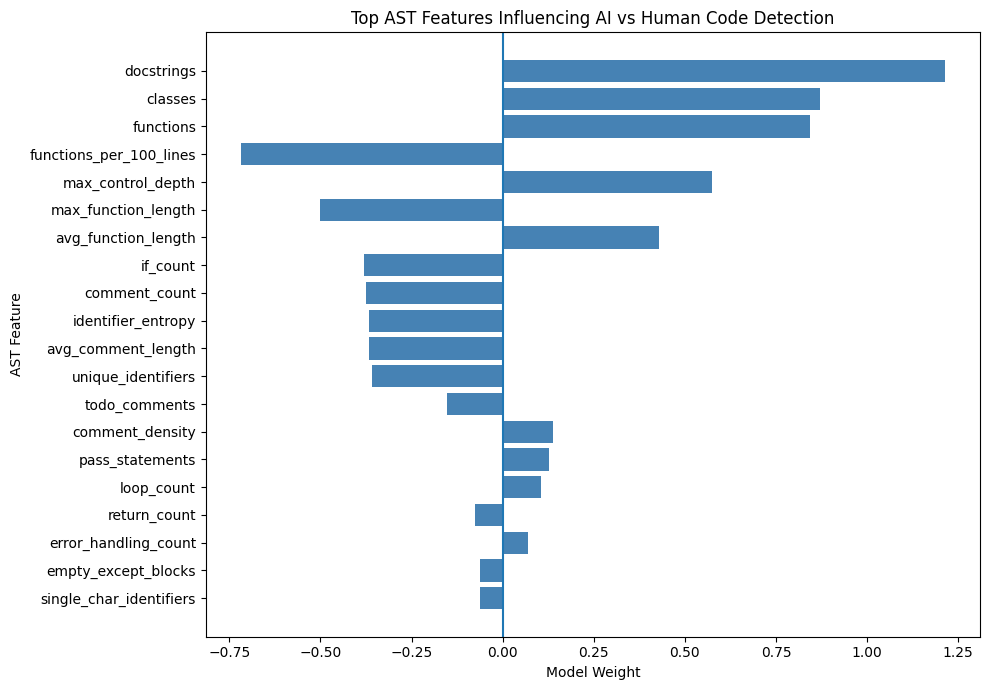

In [ ]:
extractor = ASTFeatureExtractor()

ast_feature_names = extractor.FEATURE_NAMES

print(len(ast_feature_names))

cb_feature_names = [
    f"codebert_pca_{i}" for i in range(X_train_cb.shape[1])
]

feature_names = ast_feature_names + cb_feature_names


weights = clf.coef_[0]

indices = np.argsort(np.abs(weights))[::-1]

top_k = 20

for i in indices:

    name = feature_names[i]
    weight = weights[i]

    direction = "AI" if weight > 0 else "Human"

    print(f"{name:30s}  weight={weight:.3f}  → pushes toward {direction}")

num_ast = X_train_ast.shape[1]

ast_weights = weights[:num_ast]
cb_weights = weights[num_ast:]

print("AST importance:", np.mean(np.abs(ast_weights)))
print("CodeBERT importance:", np.mean(np.abs(cb_weights)))

# Number of AST features
num_ast = len(ast_feature_names)

# Extract only AST weights
ast_weights = weights[:num_ast]

# Find most important AST features
top_k = min(20, num_ast)

indices = np.argsort(np.abs(ast_weights))[::-1][:top_k]

names = [ast_feature_names[i] for i in indices]
vals = ast_weights[indices]

plt.figure(figsize=(10,7))

plt.barh(names[::-1], vals[::-1], color="steelblue")

plt.axvline(0)

plt.title("Top AST Features Influencing AI vs Human Code Detection")
plt.xlabel("Model Weight")
plt.ylabel("AST Feature")

plt.tight_layout()
plt.show()

# Testing on GitHub Dataset

Python-only rows: 30
Final Python samples: 60
AI ratio: 0.5
Extracting AST features...
AST shape: (60, 22)
Extracting CodeBERT embeddings...
CodeBERT shape: (60, 768)
CodeBERT PCA shape: (60, 256)
Final feature shape: (60, 278)

Accuracy: 0.4667
AUROC: 0.5111


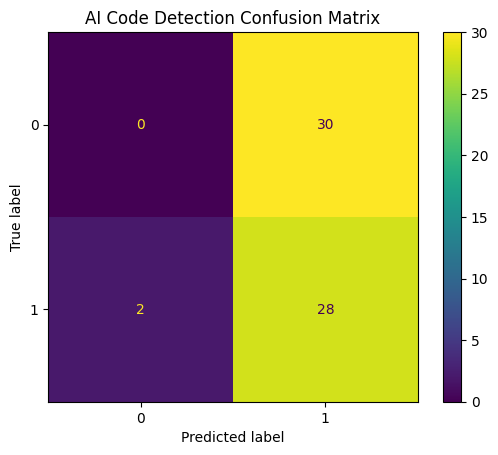

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


csv_path = "/content/drive/MyDrive/AI-Human-Generated-Program-Code-Dataset(1).csv"
df = pd.read_csv(csv_path)


df = df[df["language"].str.lower() == "python"]

print("Python-only rows:", len(df))


ai_df = df[['id','problem_number','language','difficulty',
            'generator_name','generator_type',
            'description','prompt','ai_generated_code']].copy()

ai_df = ai_df.rename(columns={'ai_generated_code':'code'})
ai_df['is_ai'] = 1


human_df = df[['id','problem_number','language','difficulty',
               'generator_name','generator_type',
               'description','prompt','human_generated_code']].copy()

human_df = human_df.rename(columns={'human_generated_code':'code'})
human_df['is_ai'] = 0


combined_df = pd.concat([ai_df, human_df], ignore_index=True)

combined_df = combined_df[
    combined_df['code'].notna() &
    (combined_df['code'].str.strip() != "")
]


combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final Python samples:", len(combined_df))
print("AI ratio:", combined_df['is_ai'].mean())

texts = combined_df['code'].tolist()
y_new = combined_df['is_ai'].values


print("Extracting AST features...")

X_new_ast = np.array(
    [ASTFeatureExtractor().extract(code) for code in texts],
    dtype=np.float32
)

X_new_ast = ast_scaler.transform(X_new_ast)

print("AST shape:", X_new_ast.shape)


print("Extracting CodeBERT embeddings...")

X_new_cb = codebert_features(texts)

print("CodeBERT shape:", X_new_cb.shape)  # (N,768)


X_new_cb = pca.transform(X_new_cb)

print("CodeBERT PCA shape:", X_new_cb.shape)  # (N,256)


X_new = np.hstack([X_new_ast, X_new_cb])

print("Final feature shape:", X_new.shape)


probs = clf.predict_proba(X_new)[:,1]
preds = (probs >= 0.5).astype(int)


acc = accuracy_score(y_new, preds)
auc = roc_auc_score(y_new, probs)

print(f"\nAccuracy: {acc:.4f}")
print(f"AUROC: {auc:.4f}")


cm = confusion_matrix(y_new, preds)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title("AI Code Detection Confusion Matrix")
plt.show()